In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [5]:
df=pd.read_csv('Height_Weight1.csv')

In [21]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [70]:
pip install statsmodels

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.5 MB 1.9 MB/s eta 0:00:05
   --- ------------------------------------ 0.8/9.5 MB 1.9 MB/s eta 0:00:05
   ------- -------------------------------- 1.8/9.5 MB 2.4 MB/s eta 0:00:04
   ---------- ----------------------------- 2.6/9.5 MB 2.7 MB/s eta 0:00:03
   ------------- -------------------------- 3.1/9.5 MB 2.6 MB/s eta 0:00:03
   ---------------- ----------------------- 3.9/9.5 MB 2.7 MB/s eta 0:00:03
   ------------------- -------------------- 4.7/9.5 MB 2.9 MB/s eta 0:00:02
   ------------------------ --------------- 5.8/9.5 MB 3.2 MB/s eta 0:00:02
   --------------------------- ------------ 6.6/9.5 MB 3.3 MB/s eta 0:00:01
   ------------------------------- -----


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


In [7]:
df.shape

(23, 2)

Text(0, 0.5, 'Height')

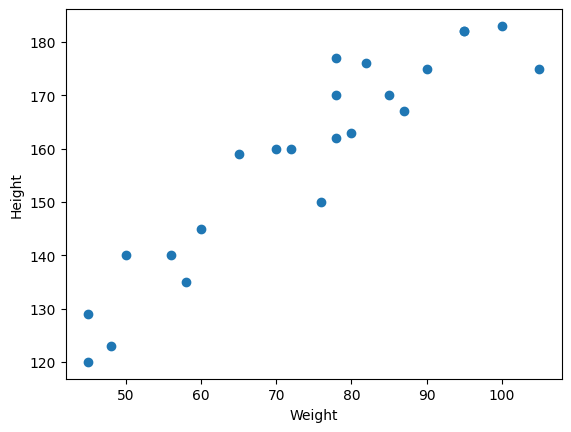

In [9]:
## Step 1 Analyze the Existing data
plt.scatter(x=df['Weight'],y=df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')

Text(0, 0.5, 'Height')

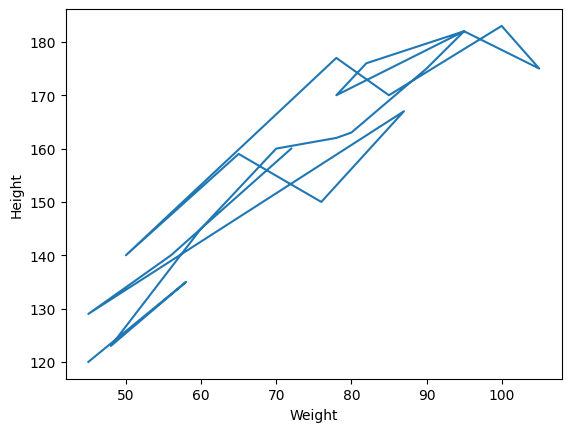

In [13]:
## Step 1 Analyze the Existing data
##plt.plot(x=df['Weight'],y=df['Height'])
plt.plot(df['Weight'],df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')

In [16]:
## Step 2 Check the correlation with Input and Output Data
df.corr()
## Conclusion Data is highly correlates

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


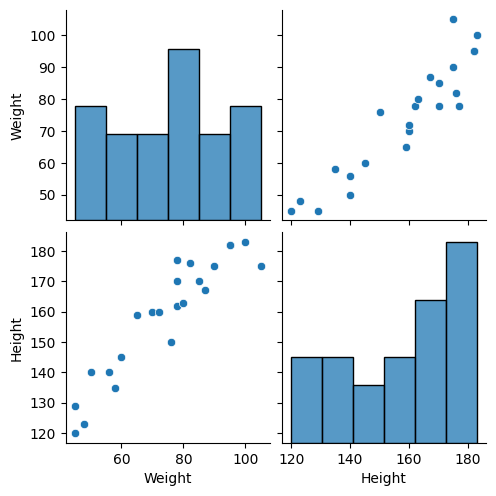

In [17]:
sns.pairplot(df)

In [32]:
## Input parameter should be dataframe
X=df[['Weight']]
X.head()

,Weight
0,45
1,58
2,48
3,60
4,70


In [33]:
## Output parameter should be in Series
y=df['Height']

In [34]:
## Step 3 
## Diffrentiate the data for train out Model
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)

In [35]:
X_train.head()

,Weight
1,58
13,100
5,78
2,48
11,95


In [36]:
y_train.head()

1     135
13    183
5     162
2     123
11    182
Name: Height, dtype: int64

In [37]:
##Now Standardize the Data to get out result as Quick
## In standardization we will do Mean as 0 and standard Deviation as 1
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [41]:
X_train=(scaler.fit_transform(X_train))

In [42]:
X_test=scaler.transform(X_test)

In [46]:
X_train
X_test

array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

In [48]:
## Now we have Standardize our data 
## Now Apply the Linear Regression
from sklearn.linear_model import LinearRegression
regression=LinearRegression(n_jobs=-1)

In [49]:
regression.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [52]:
## Now check the Slope of our line
Slope=regression.coef_
print(Slope)

[17.2982057]


In [53]:
## Check the Y Intercept
Y_intercept=regression.intercept_
print(Y_intercept)

156.47058823529412


In [ ]:
## Equation of line is looking like
## y=mx+c
## y=17.2982057x+156.47058823529412
## Test for Weight(x) as 72

##y= 17.2982057*(72)+156.47058823529412 == 1401.94
##y= 17.2982057*(-0.02850823)+156.47058823529412 == 155.97

## BEcause we have not standardize the input 72
## Standardize out of 72 is -0.02850823

In [64]:
scaler.transform([[72]])

c:\Users\ass931235\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[-0.02850823]])

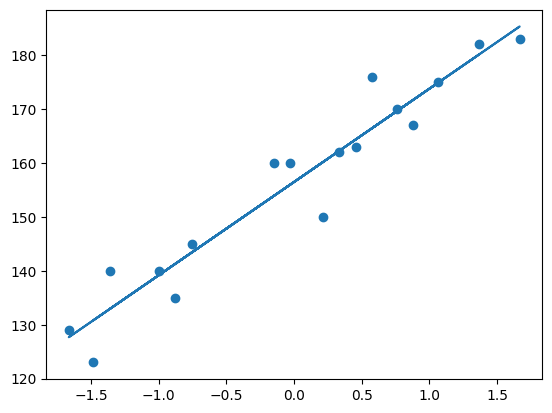

In [55]:
## now plot the graph Between X_Training and Prediction of X_Training
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train))

In [57]:
## Check the accuracy
## Predict the output for Test Data
y_pred=regression.predict(X_test)
y_pred

array([162.26499721, 162.26499721, 127.68347133, 180.07972266,
       148.64197186, 190.55897293])

In [60]:
## Check the Error  of Model using diffrent formulas
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

114.84069295228699
9.66512588679501
10.716374991212605


In [63]:
## calculate the accuracy in percentage
## 1) Calculaye R square
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print(score)

0.7360826717981276


In [68]:
## Score using Adjusted R2
## Formula= 1-[(1-R2)*(n-1)/(n-k-1)]

n=len(y_test) ## Total Data point
k=X_test.shape[1] ## Number if independent feature

AdjustedR2=1-((1-score)*(n-1))/(n-k-1)

print(AdjustedR2)



0.6701033397476595


In [72]:
## OLS Linear Regression
import statsmodels.api as sm

In [76]:
model=sm.OLS(y_train,X_train).fit()
model

In [80]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Sun, 18 Jan 2026   Prob (F-statistic):                       0.664
Time:                        18:18:05   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------